
PR_25 PRACTICAL STARTED

========== MODULE 1 : INGESTION ==========

FIRST 5 ROWS
   _id                 time    val
0    1  2016-08-18T10:55:00  50.00
1    2  2016-08-18T11:00:00  50.12
2    3  2016-08-18T11:05:00  50.00
3    4  2016-08-18T11:10:00  50.00
4    5  2016-08-18T11:15:00  51.92

PARQUET FILE CREATED SUCCESSFULLY

========== MODULE 2 : PREPARATION ==========

MONOTONICITY CHECK
Sequential Order: True

FREQUENCY INSPECTION
Frequency StdDev: 30470.90223263589

MISSING VALUE CHECK
val    0.0
dtype: float64

RESAMPLING DATA
                       val
time                      
2016-08-18 10:45:00  50.00
2016-08-18 11:00:00  50.04
2016-08-18 11:15:00  51.41
2016-08-18 11:30:00  50.27
2016-08-18 11:45:00  50.00

INTERPOLATING MISSING VALUES
                       val
time                      
2016-08-18 10:45:00  50.00
2016-08-18 11:00:00  50.04
2016-08-18 11:15:00  51.41
2016-08-18 11:30:00  50.27
2016-08-18 11:45:00  50.00

========== MODULE 3 : EXPLORATION ==========

STATIS

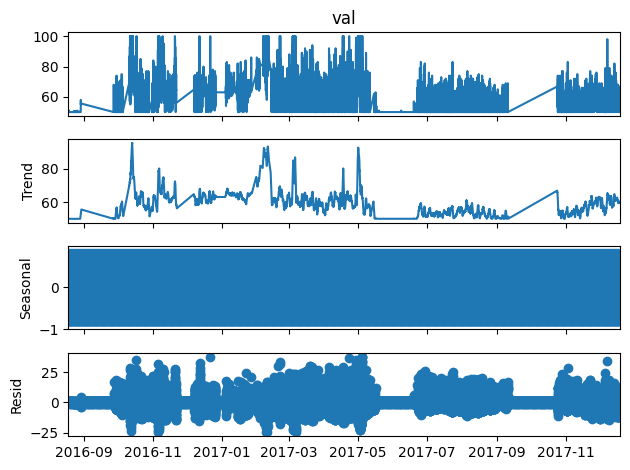

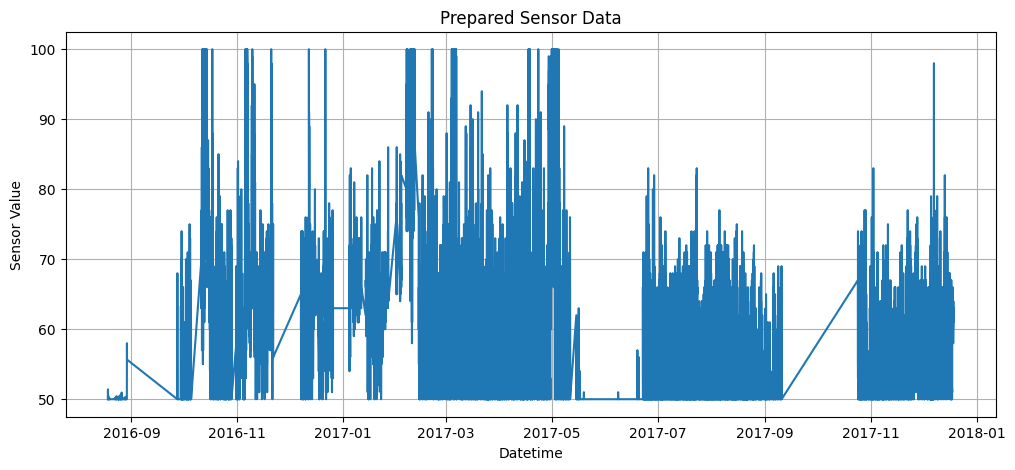


PRACTICAL COMPLETED SUCCESSFULLY


In [3]:
# ==========================================
# PR_25
# Representation and Statistical Exploration
# of Datasets Through Modular Workflow Operations
# Sensor Data Dataset
# ==========================================

# ---------- IMPORT LIBRARIES ----------

import pandas as pd
import matplotlib.pyplot as plt

from statsmodels.tsa.seasonal import seasonal_decompose

# ==========================================
# MODULE 1 : STRUCTURED INGESTION
# ==========================================

def ingestion_module():

    """
    DEFINITION:
    Structured ingestion transfers data from
    source storage into analytical format
    while preserving datetime structure.
    """

    print("\n========== MODULE 1 : INGESTION ==========")

    # Load dataset
    df = pd.read_csv("sensor_data.csv")

    print("\nFIRST 5 ROWS")
    print(df.head())

    # Convert datetime column
    df['time'] = pd.to_datetime(
        df['time'],
        errors='coerce'
    )

    # Remove invalid datetime rows
    df = df.dropna(subset=['time'])

    # Set datetime index
    df = df.set_index('time')

    # Sort sequentially
    df = df.sort_index()

    # Convert sensor values to numeric
    df['val'] = pd.to_numeric(
        df['val'],
        errors='coerce'
    )

    # Remove invalid values
    df = df.dropna(subset=['val'])

    # Keep required column
    df = df[['val']]

    # Save as Parquet
    df.to_parquet(
        "sensor_data_cache.parquet",
        compression='snappy'
    )

    print("\nPARQUET FILE CREATED SUCCESSFULLY")

    return df


# ==========================================
# MODULE 2 : DATA PREPARATION
# ==========================================

def preparation_module():

    """
    DEFINITION:
    Preparation ensures temporal integrity
    using monotonicity validation,
    resampling, and interpolation.
    """

    print("\n========== MODULE 2 : PREPARATION ==========")

    # Load parquet file
    df = pd.read_parquet(
        "sensor_data_cache.parquet"
    )

    # ---------- MONOTONICITY CHECK ----------

    print("\nMONOTONICITY CHECK")

    is_monotonic = (
        df.index.is_monotonic_increasing
    )

    print("Sequential Order:", is_monotonic)

    # Fix if not monotonic
    if not is_monotonic:
        df = df.sort_index()

    # ---------- FREQUENCY INSPECTION ----------

    print("\nFREQUENCY INSPECTION")

    time_deltas = (
        df.index.to_series()
        .diff()
        .dt.total_seconds()
    )

    freq_std = time_deltas.std()

    print("Frequency StdDev:", freq_std)

    # ---------- MISSING VALUE CHECK ----------

    print("\nMISSING VALUE CHECK")

    missing_ratio = (
        df.isnull().mean() * 100
    )

    print(missing_ratio)

    # ---------- RESAMPLING ----------

    print("\nRESAMPLING DATA")

    # Convert irregular data
    # into 15-minute intervals
    df_resampled = (
        df
        .resample('15min')
        .mean()
    )

    print(df_resampled.head())

    # ---------- INTERPOLATION ----------

    print("\nINTERPOLATING MISSING VALUES")

    df_resampled['val'] = (
        df_resampled['val']
        .interpolate(method='time')
    )

    print(df_resampled.head())

    return df_resampled


# ==========================================
# MODULE 3 : STATISTICAL EXPLORATION
# ==========================================

def exploration_module(df):

    """
    DEFINITION:
    Statistical exploration decomposes
    the dataset into trend, seasonality,
    and residual noise.
    """

    print("\n========== MODULE 3 : EXPLORATION ==========")

    # ---------- STATISTICAL SUMMARY ----------

    print("\nSTATISTICAL SUMMARY")

    stats = df['val'].describe()

    print(stats)

    # ---------- SEASONAL DECOMPOSITION ----------

    print("\nPERFORMING SIGNAL DECOMPOSITION")

    decomposition = seasonal_decompose(
        df['val'],
        model='additive',
        period=96
    )

    # ---------- VISUALIZATION ----------

    decomposition.plot()

    plt.show()

    # ---------- DATA VISUALIZATION ----------

    plt.figure(figsize=(12,5))

    plt.plot(df['val'])

    plt.title("Prepared Sensor Data")

    plt.xlabel("Datetime")

    plt.ylabel("Sensor Value")

    plt.grid(True)

    plt.show()

    return stats


# ==========================================
# MAIN EXECUTION
# ==========================================

print("\n===================================")
print("PR_25 PRACTICAL STARTED")
print("===================================")

# MODULE 1
ingestion_module()

# MODULE 2
prepared_df = preparation_module()

# MODULE 3
statistics = exploration_module(
    prepared_df
)

print("\n===================================")
print("PRACTICAL COMPLETED SUCCESSFULLY")
print("===================================")